In [61]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [62]:
from src.utils.io import load_excel

DATA_DIR = PROJECT_ROOT / "data"

dataset = load_excel(
    DATA_DIR /
    "processed" /
    "processed_elec-prot" /
    "elec-prot.xlsx"
)

In [63]:
features = ["MDR", "PW", "Frequency", "NoP", "TD", "Particle", "Target"]

X= dataset[features]
y = dataset["Endpoint"]

titles = dataset["Title"]

In [ ]:
"""
The dataset is partitioned into 7 subsets. From this partitioning, seven distinct dataframes are generated, each corresponding 
to a different fold in which one subset is used as the validation set and the remaining six subsets constitute the training set.
Data augmentation is performed by generating three variants for each instance. 


For future reference, the StandardScaler must be fitted exclusively on the training data. After fitting the scaler and training 
the model on the scaled training set, the validation set should be transformed using the scaler parameters derived from the 
training data.
"""

'\nThe dataset is partitioned into 7 subsets. From this partitioning, seven distinct dataframes are generated, each corresponding \nto a different fold in which one subset is used as the validation set and the remaining six subsets constitute the training set.\nData augmentation is performed by generating four variants for each instance. This choice compensates for the reduced amount of \ntraining data when using seven folds instead of five.\n\n\nFor future reference, the StandardScaler must be fitted exclusively on the training data. After fitting the scaler and training \nthe model on the scaled training set, the validation set should be transformed using the scaler parameters derived from the \ntraining data.\n'

In [65]:
from src.models.augmentation_df import build_augmented_kfold_datasets
number_of_folds = 7
datasets = build_augmented_kfold_datasets(
    X=X,
    y=y,
    num_variants=3,       # number of augmented instances
    n_splits=number_of_folds,  
    random_state=1
)

In [66]:
"""  
The distribution of the features was plotted for each fold to highlight potential differences between the training and validation 
sets. This analysis proved useful for adjusting the augmentation parameters, ultimately leading to the decision to apply the same 
sigma value (0.001) across all features.
"""

'  \nThe distribution of the features was plotted for each fold to highlight potential differences between the training and validation \nsets. This analysis proved useful for adjusting the augmentation parameters, ultimately leading to the decision to apply the same \nsigma value (0.001) across all features.\n'

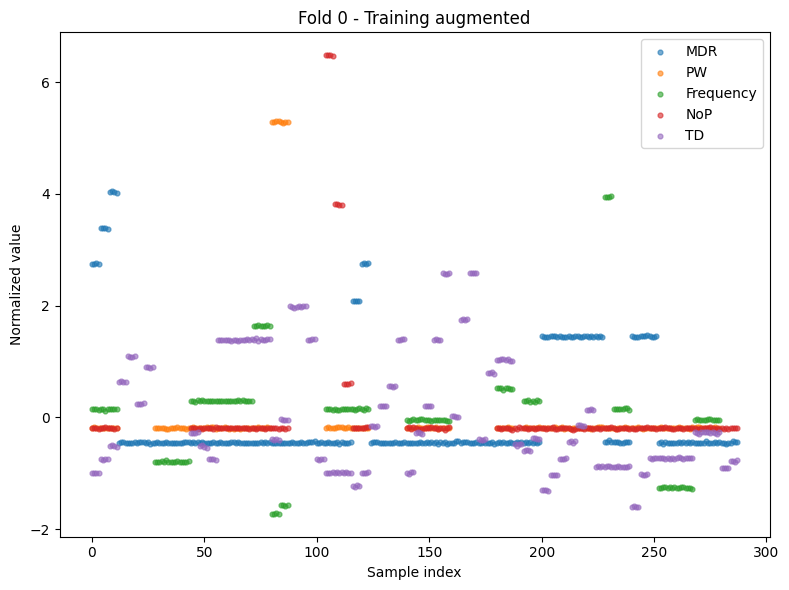

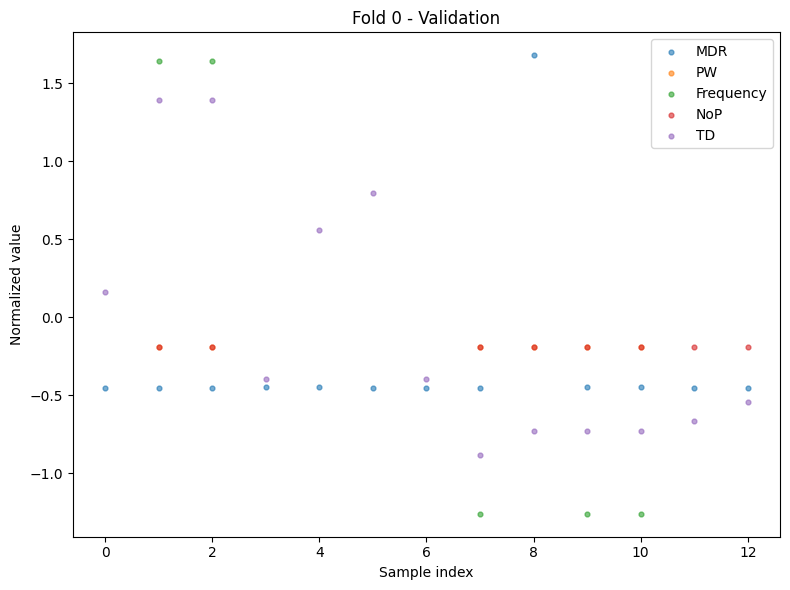

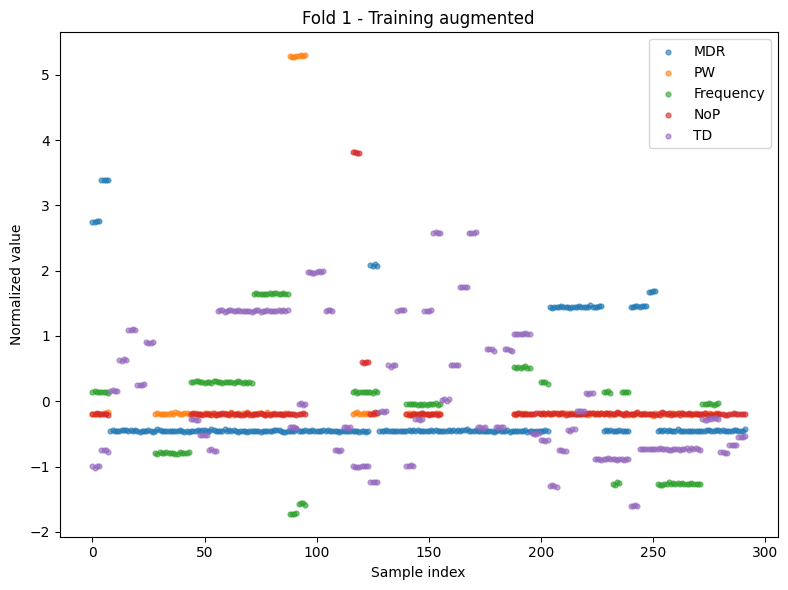

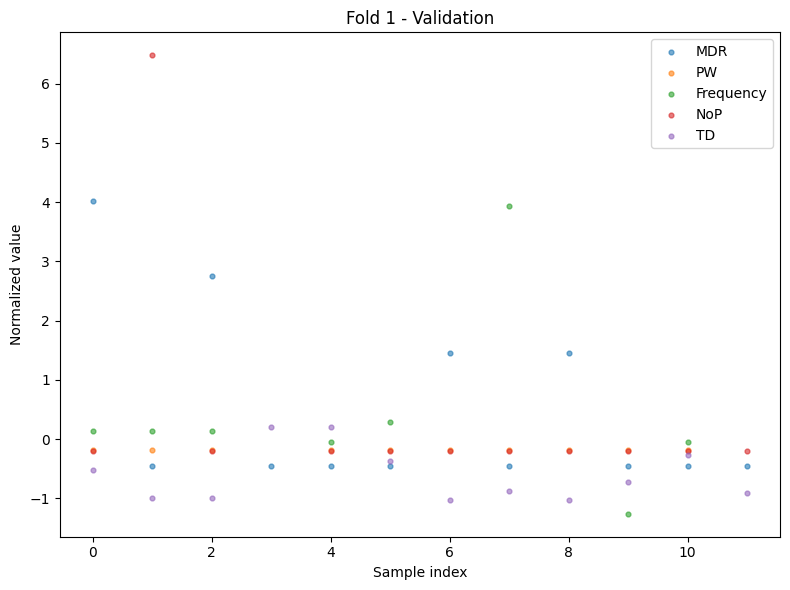

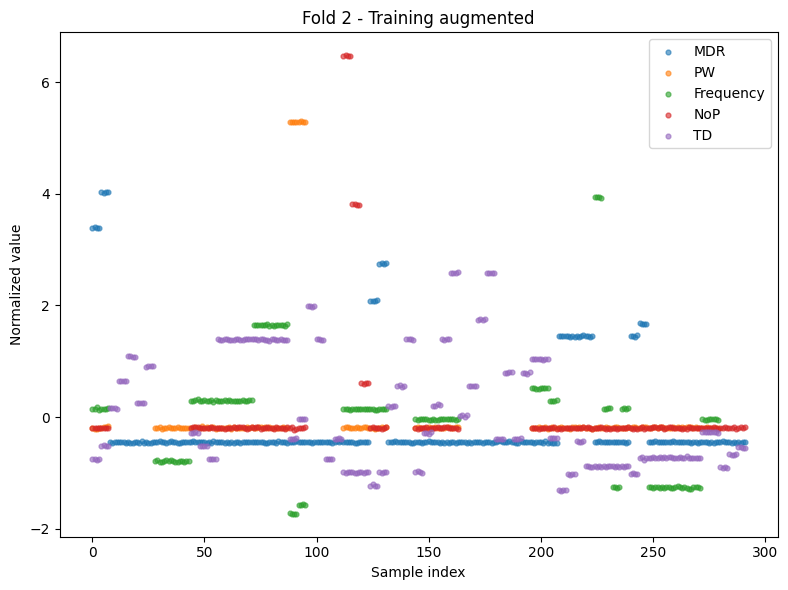

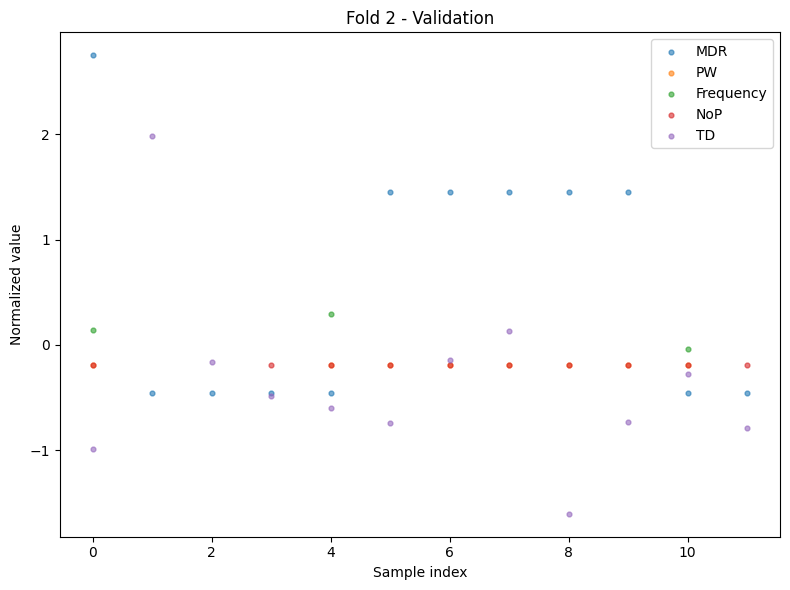

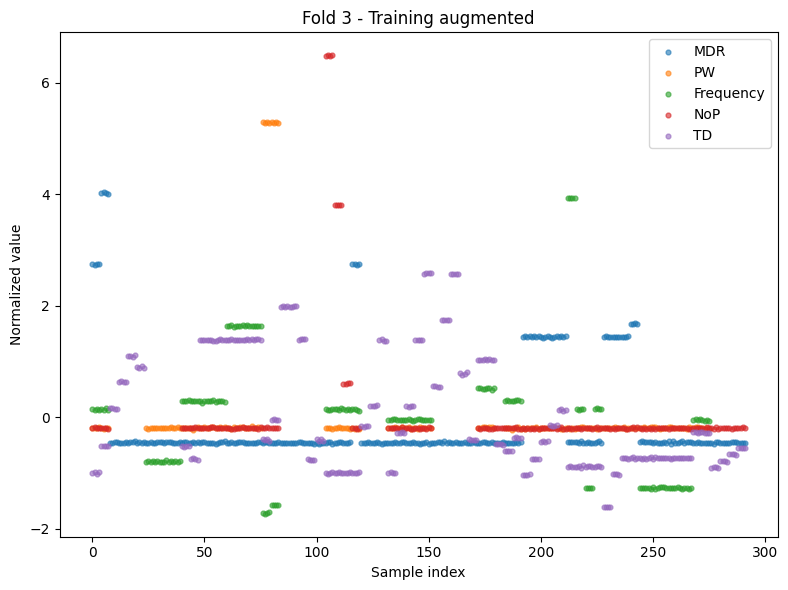

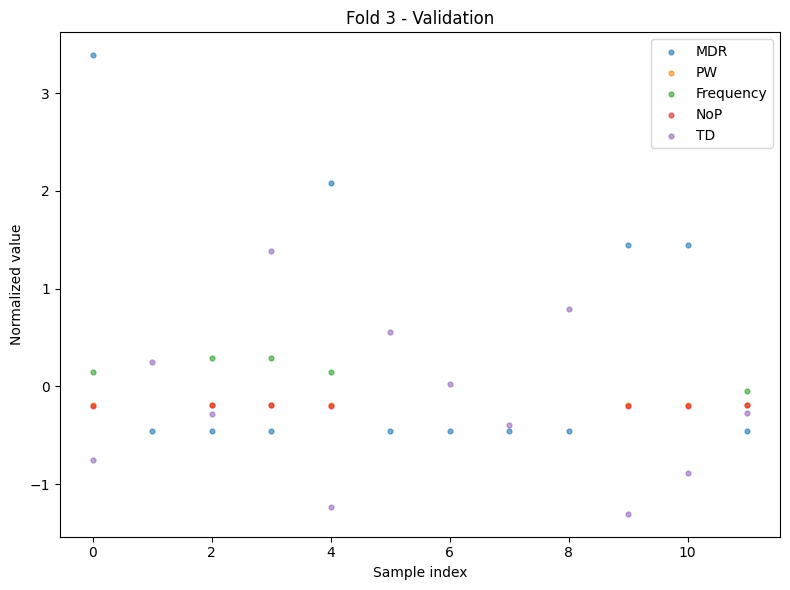

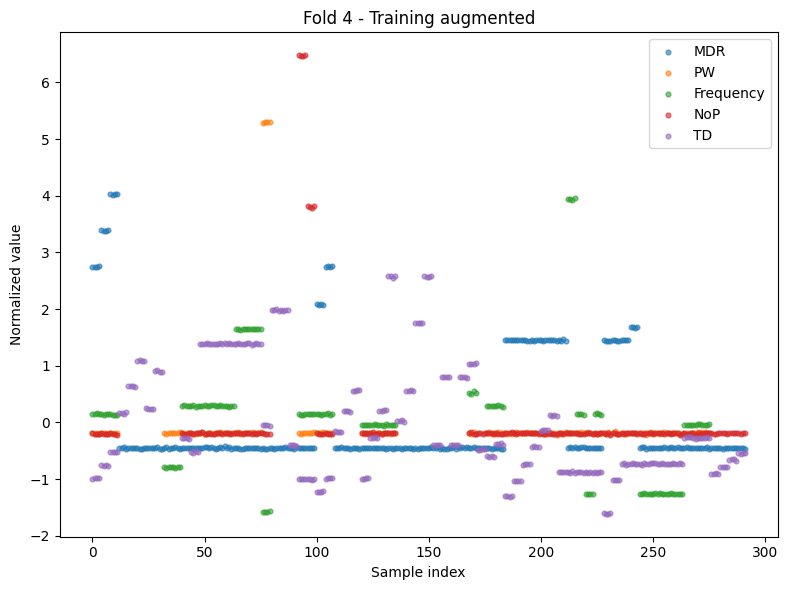

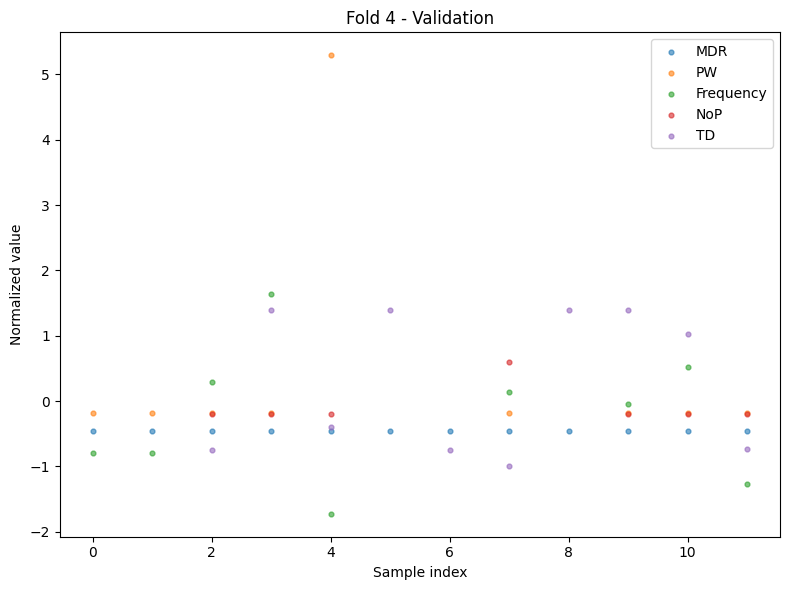

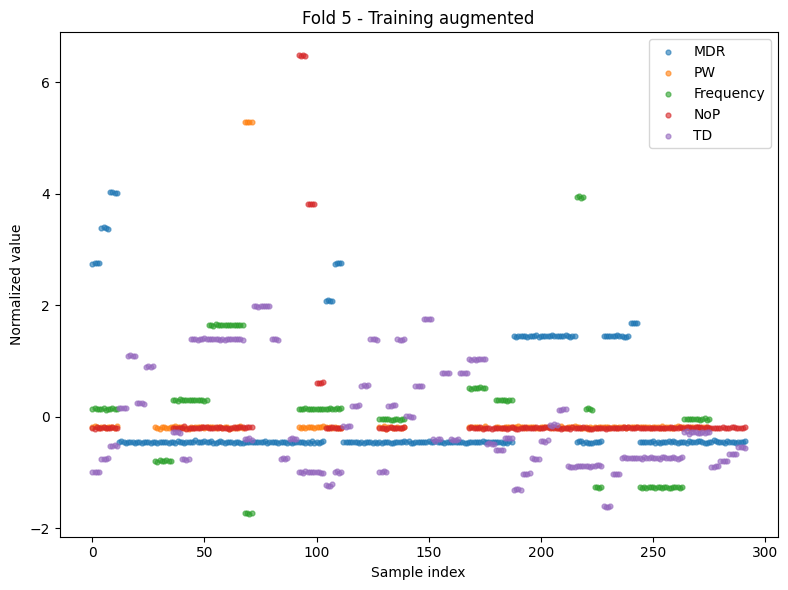

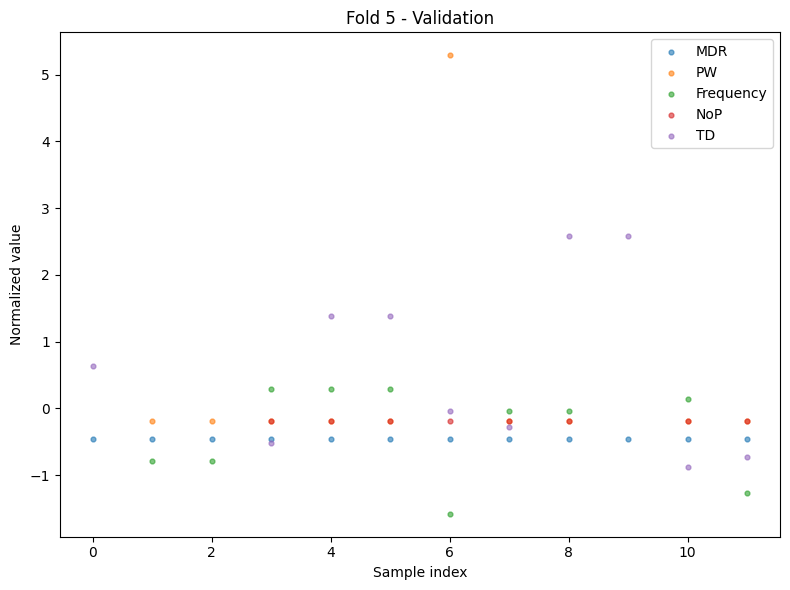

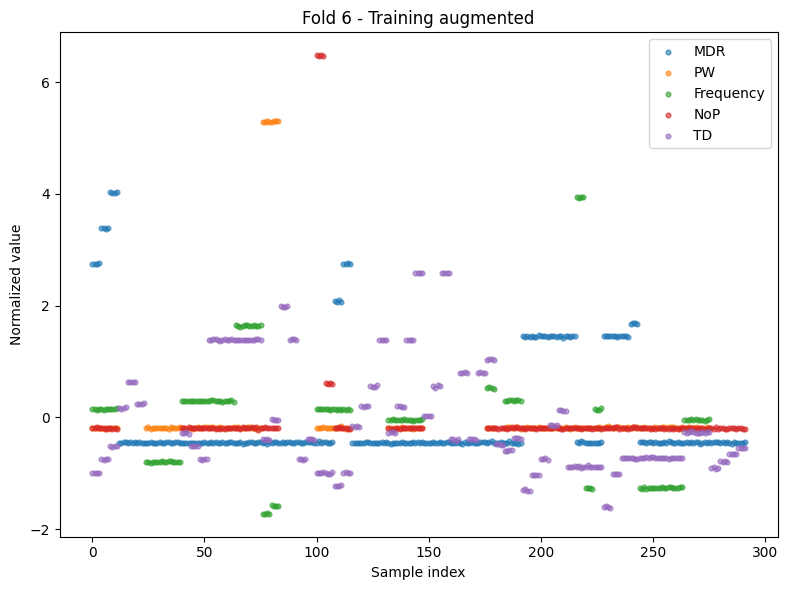

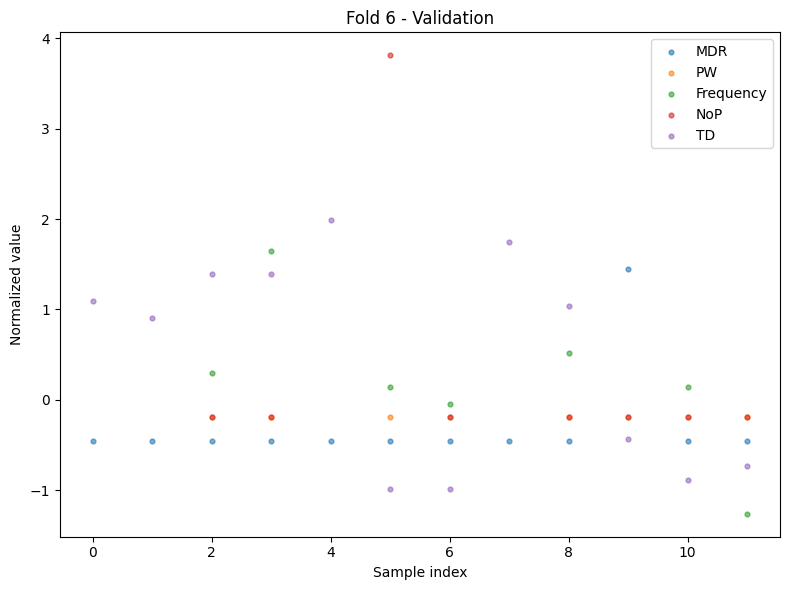

In [67]:
from src.models.augmentation_df import plot_feature_distributions

for i in range(number_of_folds):
    plot_feature_distributions(
    datasets[i]["X_train"],
    title=f"Fold {i} - Training augmented"
    )
    plot_feature_distributions(
    datasets[i]["X_val"],
    title=f"Fold {i} - Validation"
    )


In [68]:
""" 
A Grid Search was performed to identify the optimal model parameters, using accuracy as the scoring metric. While this approach 
proved effective, alternative evaluation metrics (such as f1 or auc) could be considered in future work.
"""

' \nA Grid Search was performed to identify the optimal model parameters, using accuracy as the scoring metric. While this approach \nproved effective, alternative evaluation metrics (such as f1 or auc) could be considered in future work.\n'

In [69]:
from sklearn.ensemble import RandomForestClassifier
param_grid ={
    'n_estimators': [1000],
    'max_depth': [None],
    'min_samples_split': [2],
    'min_samples_leaf': [1, 2]
}
#k=7, 1000, none, 2,1

In [70]:
from src.models.augmentation_df import grid_search_classification

search = grid_search_classification(
    datasets=datasets,
    model_class=RandomForestClassifier,
    param_grid=param_grid,
    scoring="accuracy"
)

print("Best parameters:", search["best_params"])
print("Best scores:", search["best_scores"])


Best parameters: {'n_estimators': 1000, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
Best scores: {'params': {'n_estimators': 1000, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}, 'accuracy_mean': np.float64(0.6932234432234432), 'accuracy_std': np.float64(0.09862088917174107), 'f1_mean': np.float64(0.6756110486152502), 'f1_std': np.float64(0.11180073628141375), 'auc_mean': np.float64(0.7056122448979593), 'auc_std': np.float64(0.1196425851787519)}


In [71]:
"""
Metrics for each fold and mean values.
"""

'\nMetrics for each fold and mean values.\n'

In [72]:
from src.models.augmentation_df import evaluate_classification_folds
best_model_rf = RandomForestClassifier(**search["best_params"])

results = evaluate_classification_folds(
    datasets=datasets,
    model=best_model_rf
)

Fold 0:
  Accuracy: 0.7692
  F1-score: 0.7636
  ROC AUC:  0.7250
----------------------------------------
Fold 1:
  Accuracy: 0.7500
  F1-score: 0.7483
  ROC AUC:  0.7714
----------------------------------------
Fold 2:
  Accuracy: 0.8333
  F1-score: 0.8125
  ROC AUC:  0.9143
----------------------------------------
Fold 3:
  Accuracy: 0.5833
  F1-score: 0.5804
  ROC AUC:  0.6000
----------------------------------------
Fold 4:
  Accuracy: 0.7500
  F1-score: 0.7483
  ROC AUC:  0.7714
----------------------------------------
Fold 5:
  Accuracy: 0.5833
  F1-score: 0.4958
  ROC AUC:  0.5000
----------------------------------------
Fold 6:
  Accuracy: 0.6667
  F1-score: 0.6667
  ROC AUC:  0.6286
----------------------------------------

=== SUMMARY ===
Accuracy: mean=0.7051, std=0.0892
F1-score: mean=0.6879, std=0.1052
ROC AUC:  mean=0.7015, std=0.1264


In [73]:
""" 
ROC and AUC plots
"""

' \nROC and AUC plots\n'

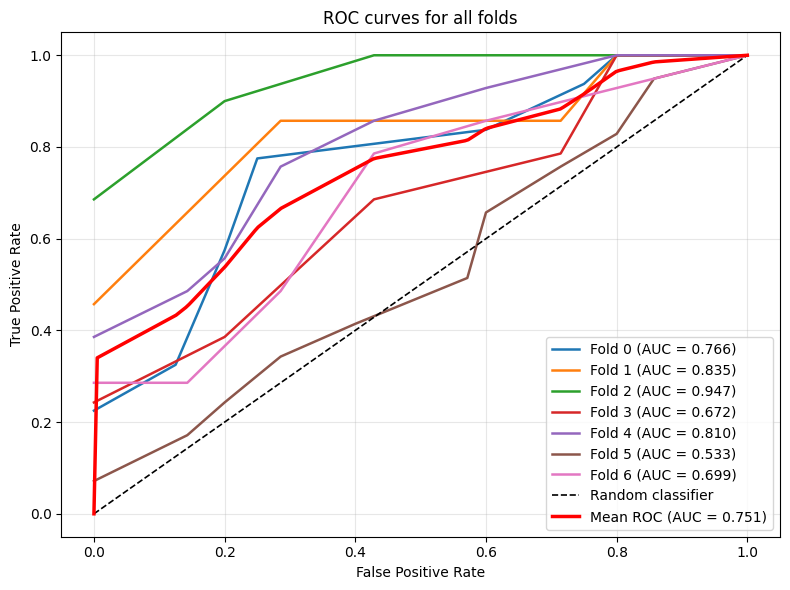

In [74]:
from src.models.augmentation_df import plot_roc
plot_roc(results)

In [75]:
"""
Model feature importance and Permutation feature importance
"""

'\nModel feature importance and Permutation feature importance\n'


 FEATURE IMPORTANCE PER FOLD 


--- Fold 1 ---
MDR             | model=0.15049 | perm=0.00000
PW              | model=0.11474 | perm=0.00000
Frequency       | model=0.13261 | perm=0.06923
NoP             | model=0.09666 | perm=0.00000
TD              | model=0.35054 | perm=0.10000
Particle        | model=0.02343 | perm=0.03846
Target          | model=0.13153 | perm=0.26154

--- Fold 2 ---
MDR             | model=0.15049 | perm=0.01667
PW              | model=0.11474 | perm=0.00000
Frequency       | model=0.13261 | perm=0.00000
NoP             | model=0.09666 | perm=0.08333
TD              | model=0.35054 | perm=0.32500
Particle        | model=0.02343 | perm=0.00000
Target          | model=0.13153 | perm=0.07500

--- Fold 3 ---
MDR             | model=0.15049 | perm=0.00000
PW              | model=0.11474 | perm=0.05000
Frequency       | model=0.13261 | perm=0.00833
NoP             | model=0.09666 | perm=0.00000
TD              | model=0.35054 | perm=0.31667
Particle        | model=0.0

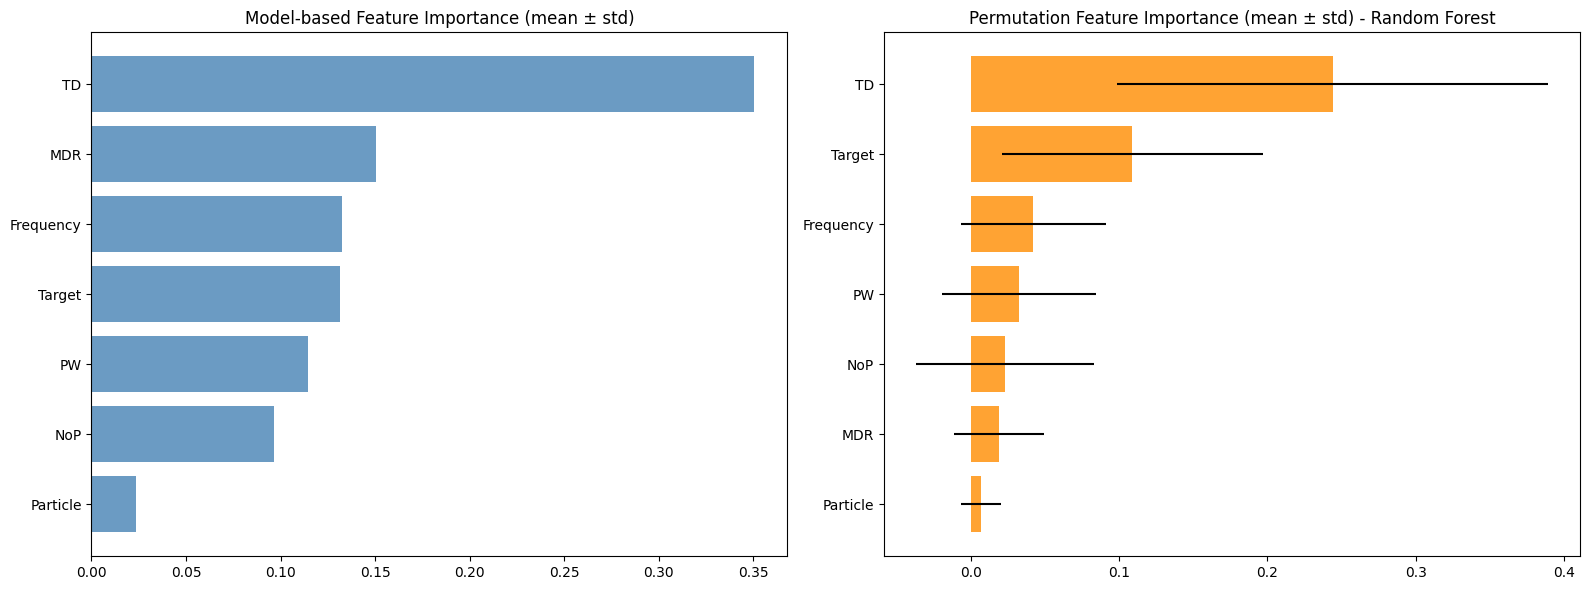

In [76]:
from src.models.augmentation_df import plot_feature_importances_across_folds
plot_feature_importances_across_folds(
    model=best_model_rf,
    datasets=datasets,
    model_name="Random Forest",
)



In [77]:
"""
SHAP feature importance with SHAP summary plot for each fold. 
"""

'\nSHAP feature importance with SHAP summary plot for each fold. \n'


 SHAP FEATURE IMPORTANCE PER FOLD 

SHAP array shape: (13, 7, 2)

Feature ranking:
TD                   0.129409
Target               0.126903
Frequency            0.066154
NoP                  0.045518
PW                   0.040494
Particle             0.027784
MDR                  0.023490

Generating SHAP summary plot...


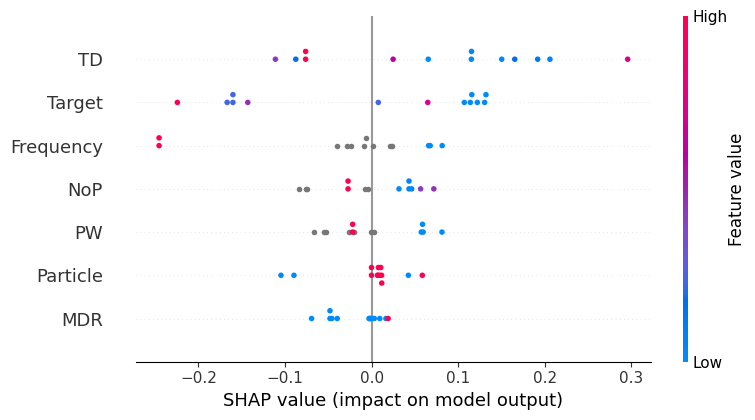

SHAP array shape: (12, 7, 2)

Feature ranking:
TD                   0.216019
Target               0.079681
Frequency            0.055697
NoP                  0.055646
PW                   0.048851
MDR                  0.035664
Particle             0.008153

Generating SHAP summary plot...


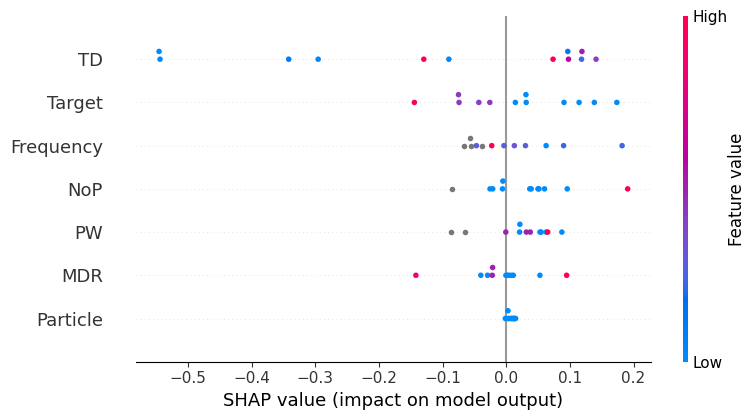

SHAP array shape: (12, 7, 2)

Feature ranking:
TD                   0.177848
Target               0.117639
PW                   0.054241
NoP                  0.043415
MDR                  0.036524
Frequency            0.028680
Particle             0.013548

Generating SHAP summary plot...


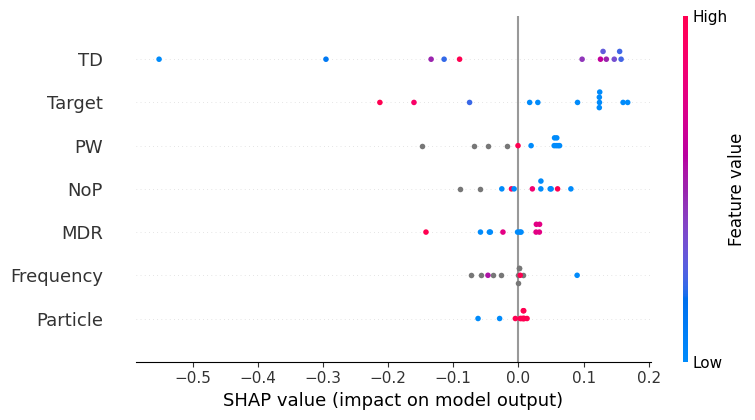

SHAP array shape: (12, 7, 2)

Feature ranking:
TD                   0.174325
Target               0.094369
MDR                  0.039910
Frequency            0.035060
NoP                  0.029827
PW                   0.027831
Particle             0.022279

Generating SHAP summary plot...


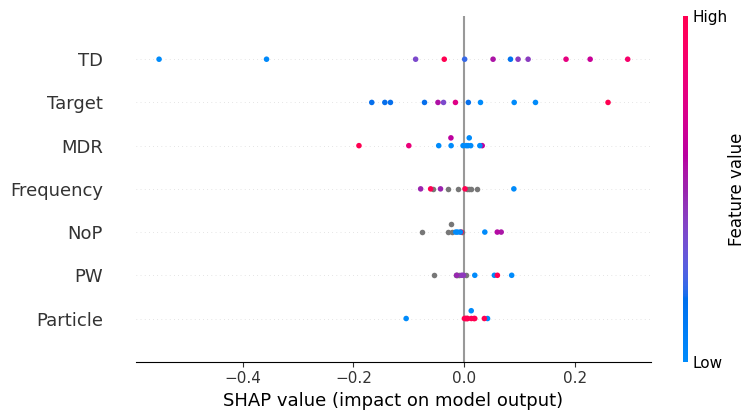

SHAP array shape: (12, 7, 2)

Feature ranking:
TD                   0.098868
Target               0.081815
Frequency            0.076144
PW                   0.059972
NoP                  0.043487
MDR                  0.032389
Particle             0.020190

Generating SHAP summary plot...


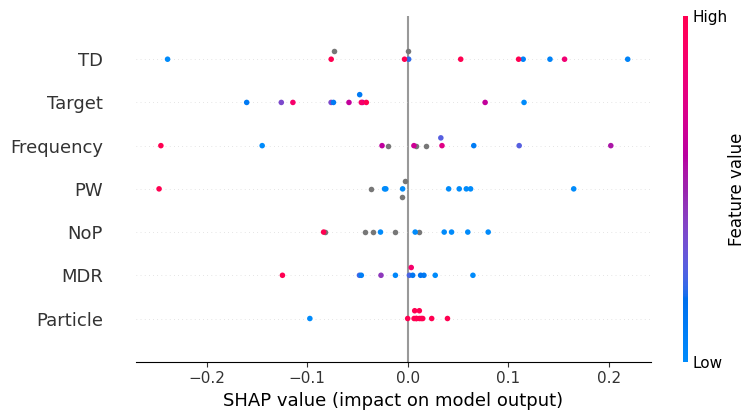

SHAP array shape: (12, 7, 2)

Feature ranking:
Target               0.112353
Frequency            0.089207
PW                   0.068522
TD                   0.057121
NoP                  0.038718
MDR                  0.023863
Particle             0.016575

Generating SHAP summary plot...


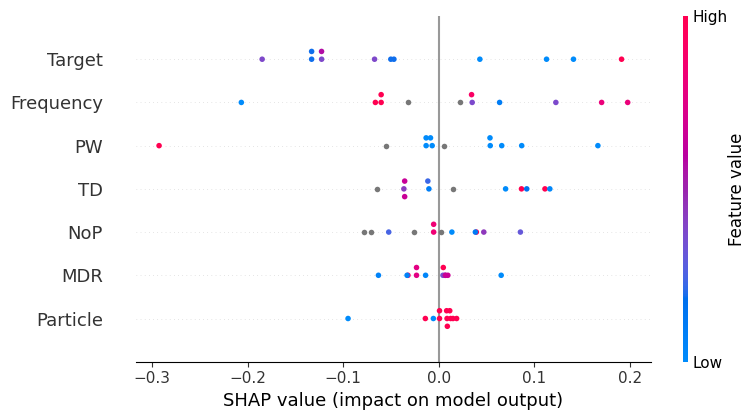

SHAP array shape: (12, 7, 2)

Feature ranking:
Target               0.122958
TD                   0.116273
Frequency            0.057882
NoP                  0.053127
PW                   0.042002
MDR                  0.028268
Particle             0.018385

Generating SHAP summary plot...


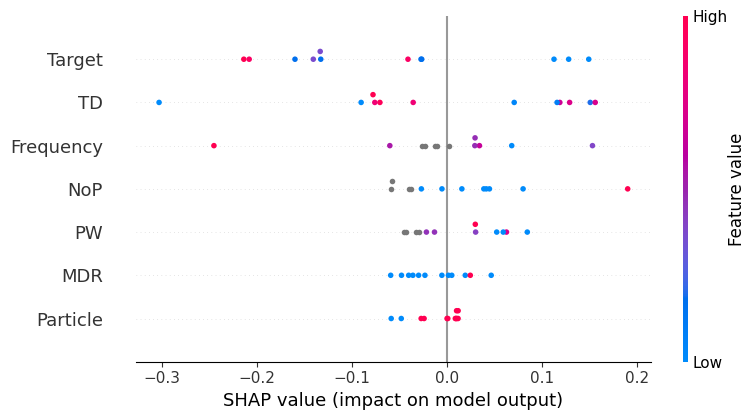


 SHAP IMPORTANCE (MEAN ± STD)

TD                   mean=0.138552 std=0.050158
Target               mean=0.105102 std=0.018156
Frequency            mean=0.058403 std=0.019855
PW                   mean=0.048845 std=0.012526
NoP                  mean=0.044248 std=0.008019
MDR                  mean=0.031444 std=0.005940
Particle             mean=0.018130 std=0.005827


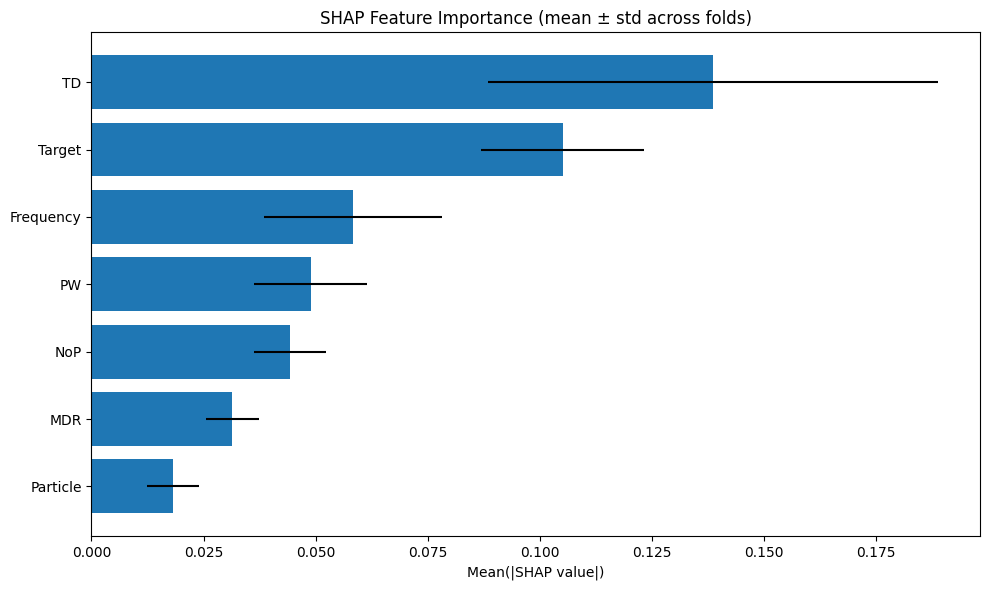

In [78]:
from src.models.augmentation_df import shap_summary_across_folds
shap_summary_across_folds(
    model=best_model_rf,
    datasets=datasets,
    max_display=20
)